In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Rutas a los archivos
DATA_DIR = Path(".")
YA_FILE      = DATA_DIR / "goodreads_reviews_young_adult.json"
SPOILER_FILE = DATA_DIR / "goodreads_reviews_spoiler_raw.json"
BOOKS_FILE   = DATA_DIR / "goodreads_books_young_adult.json"

print("Archivos encontrados:")
for f in [YA_FILE, SPOILER_FILE, BOOKS_FILE]:
    size = f.stat().st_size / (1024**3)
    print(f"  ✓ {f.name}  ({size:.2f} GB)")

Archivos encontrados:
  ✓ goodreads_reviews_young_adult.json  (2.57 GB)
  ✓ goodreads_reviews_spoiler_raw.json  (1.84 GB)
  ✓ goodreads_books_young_adult.json  (0.46 GB)


In [2]:
# Leer las primeras 5000 líneas del dataset YA para exploración
# (no cargamos todo porque son 2.5GB)
print("Cargando muestra del dataset Young Adult...")

records = []
with open(YA_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 5000:
            break
        records.append(json.loads(line))

df_ya = pd.DataFrame(records)
print(f"Filas cargadas: {len(df_ya)}")
print(f"\nColumnas disponibles: {list(df_ya.columns)}")
print(f"\nPrimeras 2 reseñas:")
df_ya[["review_text", "rating"]].head(2)

Cargando muestra del dataset Young Adult...
Filas cargadas: 5000

Columnas disponibles: ['user_id', 'book_id', 'review_id', 'rating', 'review_text', 'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes', 'n_comments']

Primeras 2 reseñas:


,review_text,rating
0,I cracked and finally picked this up. Very enj...,5
1,I read this book because my fifth grade son wa...,5


In [3]:
# Distribución de ratings y calidad del texto
print("=== Distribución de ratings ===")
print(df_ya["rating"].value_counts().sort_index())

print("\n=== Calidad del texto ===")
print(f"Reseñas con texto vacío: {(df_ya['review_text'] == '').sum()}")
print(f"Reseñas con texto nulo:  {df_ya['review_text'].isna().sum()}")
print(f"Longitud promedio (caracteres): {df_ya['review_text'].str.len().mean():.0f}")
print(f"Longitud mínima: {df_ya['review_text'].str.len().min()}")
print(f"Longitud máxima: {df_ya['review_text'].str.len().max()}")

print("\n=== Ejemplo de reseña completa ===")
print(df_ya["review_text"].iloc[0])

=== Distribución de ratings ===
rating
0     202
1     124
2     299
3    1015
4    1765
5    1595
Name: count, dtype: int64

=== Calidad del texto ===
Reseñas con texto vacío: 1
Reseñas con texto nulo:  0
Longitud promedio (caracteres): 871
Longitud mínima: 0
Longitud máxima: 13841

=== Ejemplo de reseña completa ===
I cracked and finally picked this up. Very enjoyable quick read - couldn't put it down - it was like crack. 
 I'm a bit bothered by the lack of backstory of how Panem and the Hunger Games come about. It is just kind of explained away in a few paragraphs and we are left to accept this very strange world where teenagers are pitted into an arena each year to kill each other? I was expecting it because I've seen Battle Royale, but I would have appreciated knowing more of the backstory of how the world could have come into such a odd state. 
 I suppose what makes a book like this interesting is thinking about the strategy of it all. The players are going to be statistically en

In [5]:
# Explorar estructura real del dataset de spoilers
print("Cargando muestra del dataset de spoilers...")

records_sp = []
with open(SPOILER_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 5000:
            break
        records_sp.append(json.loads(line))

df_sp = pd.DataFrame(records_sp)
print(f"Filas cargadas: {len(df_sp)}")
print(f"\nColumnas disponibles: {list(df_sp.columns)}")

# Ver un registro completo para entender la estructura
print("\n=== Registro completo (raw) ===")
import pprint
pprint.pprint(records_sp[0])

Cargando muestra del dataset de spoilers...
Filas cargadas: 5000

Columnas disponibles: ['user_id', 'book_id', 'review_id', 'rating', 'review_text', 'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes', 'n_comments']

=== Registro completo (raw) ===
{'book_id': '18245960',
 'date_added': 'Sun Jul 30 07:44:10 -0700 2017',
 'date_updated': 'Wed Aug 30 00:00:26 -0700 2017',
 'n_comments': 1,
 'n_votes': 28,
 'rating': 5,
 'read_at': 'Sat Aug 26 12:05:52 -0700 2017',
 'review_id': 'dfdbb7b0eb5a7e4c26d59a937e2e5feb',
 'review_text': 'This is a special book. It started slow for about the first '
                'third, then in the middle third it started to get '
                'interesting, then the last third blew my mind. This is what I '
                'love about good science fiction - it pushes your thinking '
                'about where things can go. \n'
                ' It is a 2015 Hugo winner, and translated from its original '
                'Chinese, which made 

In [6]:
# El campo has_spoiler está en el texto mismo
# Vamos a extraerlo detectando la etiqueta (hide spoiler)

df_sp["has_spoiler"] = df_sp["review_text"].str.contains(
    r"\(hide spoiler\)", case=False, regex=True, na=False
)

print("=== Distribución de spoilers (extraído del texto) ===")
print(df_sp["has_spoiler"].value_counts())

pct = df_sp["has_spoiler"].mean() * 100
print(f"\n{pct:.1f}% de reseñas contienen spoiler")

print("\n=== Ejemplo reseña CON spoiler ===")
ejemplo = df_sp[df_sp["has_spoiler"] == True]["review_text"].iloc[0]
print(ejemplo[:600])

=== Distribución de spoilers (extraído del texto) ===
has_spoiler
False    4706
True      294
Name: count, dtype: int64

5.9% de reseñas contienen spoiler

=== Ejemplo reseña CON spoiler ===
This is a special book. It started slow for about the first third, then in the middle third it started to get interesting, then the last third blew my mind. This is what I love about good science fiction - it pushes your thinking about where things can go. 
 It is a 2015 Hugo winner, and translated from its original Chinese, which made it interesting in just a different way from most things I've read. For instance the intermixing of Chinese revolutionary history - how they kept accusing people of being "reactionaries", etc. 
 It is a book about science, and aliens. The science described in the


In [7]:
# Resumen final del EDA
print("=" * 50)
print("     RESUMEN EDA — GOODREADS NLP MULTITASK")
print("=" * 50)

print("\n📚 DATASET YOUNG ADULT")
print(f"  Muestra explorada:     {len(df_ya):,} reseñas")
print(f"  Ratings disponibles:   {sorted(df_ya['rating'].unique())}")
print(f"  Rating 0 (sin rating): {(df_ya['rating'] == 0).sum()} → se filtrarán")
print(f"  Texto vacío:           {(df_ya['review_text'].str.len() == 0).sum()}")
print(f"  Longitud promedio:     {df_ya['review_text'].str.len().mean():.0f} caracteres")

print("\n🚨 DATASET SPOILERS")
print(f"  Muestra explorada:     {len(df_sp):,} reseñas")
print(f"  Con spoiler:           {df_sp['has_spoiler'].sum()} ({df_sp['has_spoiler'].mean()*100:.1f}%)")
print(f"  Sin spoiler:           {(~df_sp['has_spoiler']).sum()}")
print(f"  ⚠ Desbalance de clases — requiere manejo especial")

print("\n✅ COLUMNAS CLAVE CONFIRMADAS")
print(f"  review_text  → input del modelo")
print(f"  rating       → label Tarea 1 (filtrar rating=0)")
print(f"  has_spoiler  → label Tarea 2 (extraído del texto)")
print(f"  emotion      → label Tarea 3 (generar con modelo)")

print("\n🔜 SIGUIENTE PASO: Preprocesamiento completo")

     RESUMEN EDA — GOODREADS NLP MULTITASK

📚 DATASET YOUNG ADULT
  Muestra explorada:     5,000 reseñas
  Ratings disponibles:   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Rating 0 (sin rating): 202 → se filtrarán
  Texto vacío:           1
  Longitud promedio:     871 caracteres

🚨 DATASET SPOILERS
  Muestra explorada:     5,000 reseñas
  Con spoiler:           294 (5.9%)
  Sin spoiler:           4706
  ⚠ Desbalance de clases — requiere manejo especial

✅ COLUMNAS CLAVE CONFIRMADAS
  review_text  → input del modelo
  rating       → label Tarea 1 (filtrar rating=0)
  has_spoiler  → label Tarea 2 (extraído del texto)
  emotion      → label Tarea 3 (generar con modelo)

🔜 SIGUIENTE PASO: Preprocesamiento completo


Matplotlib is building the font cache; this may take a moment.


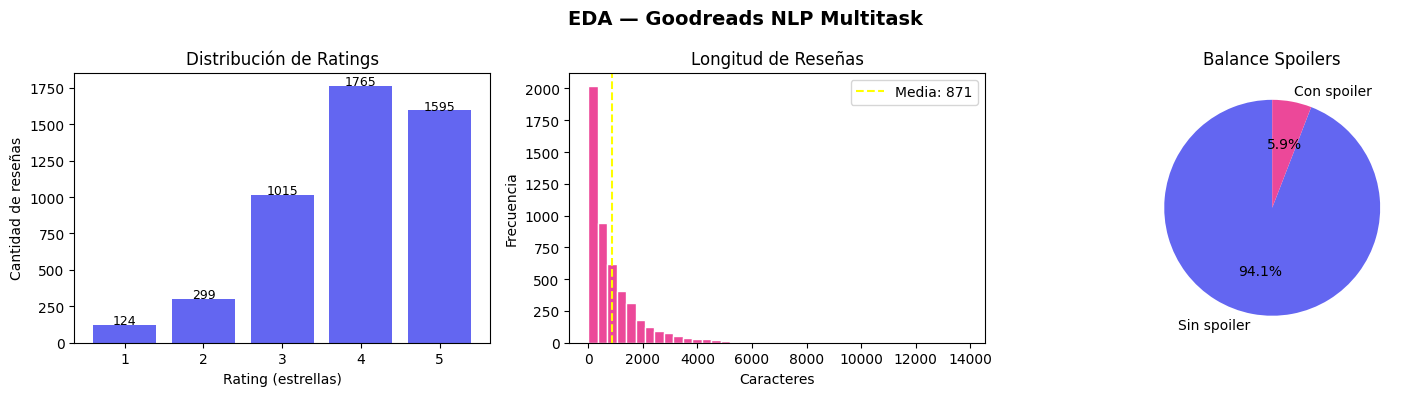

Gráfica guardada como eda_plots.png ✓


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1 — Distribución de ratings
ratings_filtrados = df_ya[df_ya["rating"] > 0]["rating"].value_counts().sort_index()
axes[0].bar(ratings_filtrados.index, ratings_filtrados.values, color="#6366f1")
axes[0].set_title("Distribución de Ratings")
axes[0].set_xlabel("Rating (estrellas)")
axes[0].set_ylabel("Cantidad de reseñas")
for i, v in enumerate(ratings_filtrados.values):
    axes[0].text(i + 1, v + 5, str(v), ha="center", fontsize=9)

# Gráfica 2 — Distribución de longitud de reseñas
longitudes = df_ya[df_ya["review_text"].str.len() > 0]["review_text"].str.len()
axes[1].hist(longitudes, bins=40, color="#ec4899", edgecolor="white")
axes[1].set_title("Longitud de Reseñas")
axes[1].set_xlabel("Caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(longitudes.mean(), color="yellow", linestyle="--", label=f"Media: {longitudes.mean():.0f}")
axes[1].legend()

# Gráfica 3 — Balance spoilers
spoiler_counts = df_sp["has_spoiler"].value_counts()
axes[2].pie(
    spoiler_counts.values,
    labels=["Sin spoiler", "Con spoiler"],
    colors=["#6366f1", "#ec4899"],
    autopct="%1.1f%%",
    startangle=90
)
axes[2].set_title("Balance Spoilers")

plt.suptitle("EDA — Goodreads NLP Multitask", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como eda_plots.png ✓")
